In [2]:
import pandas as pd

data = pd.read_csv("data/swiss_prot_ec_plants.csv")
data

,accession,name,sequence,EC,lineage,species,taxonomy_id
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
...,...,...,...,...,...,...,...
15514,Q9FLM3,ZDH23_ARATH,MYVVTPPQRSGFGSDCDLRVYQTWKGSNIFCLQGRFIFGPDVRSLG...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15515,Q8VYS8,ZDH24_ARATH,MAGRVFEAWKGSNKFLFGGRLIFGPDAWSIPFTFLLIITPVCFFSV...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15516,Q9C533,ZDHC1_ARATH,MRKHGWQLPYHPLQVVAVAVFLALGFAFYVFFAPFVGKKIHQYIAM...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702
15517,Q3EC11,ZDHC2_ARATH,MDSSEIEVVPLDSNSHQSPTESPTITDVFSASAYGDLHQLKHFVEH...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702


In [3]:
import pandas as pd
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

def csv_to_fasta(csv_file_path, fasta_file_path, id_column, sequence_column):
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(csv_file_path)
    
    # Create a list to hold SeqRecord objects
    records = []
    
    # Iterate over each row in the DataFrame
    for _, row in df.iterrows():
        # Create a SeqRecord object
        record = SeqRecord(
            Seq(row[sequence_column]),
            id=row[id_column],
            description=""
        )
        # Append the SeqRecord to the list
        records.append(record)
    
    # Write the SeqRecord objects to a FASTA file
    SeqIO.write(records, fasta_file_path, "fasta")

# Example usage
csv_file_path = "data/swiss_prot_ec_plants.csv"
fasta_file_path = "data/swiss_prot_ec_plants.fasta"
id_column = 'accession'  # Replace with the name of the column containing sequence IDs
sequence_column = 'sequence'  # Replace with the name of the column containing sequences
csv_to_fasta(csv_file_path, fasta_file_path, id_column, sequence_column)


In [6]:
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
final_dataset = mlb.divide_labels_by_EC_level("data/swiss_prot_ec_plants.csv")
final_dataset = mlb.get_final_labels(final_dataset)
final_dataset = final_dataset.sample(frac=1).reset_index(drop=True)
final_dataset

EC1 is not null


,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,7.2.2.12,7.2.2.21,7.2.2.8,7.2.2.9,7.3.2.3,7.4.2.4,7.6.2.1,7.6.2.2,7.6.2.4,7.6.2.5
0,A6MMI8,PSBA_DIOEL,MTAILERRESTSLWGRFCNWITSTENRLYIGWFGVLMIPTLLTATS...,1.10.3.9,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Dioscorea elephantipes,145284,1,1.10,1.10.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,A6MMC5,NDHJ_CHLSC,MQGRLSAWLVKHELVHRSLGFDYQGIETLQIKPEDWYSIAVISYVY...,7.1.1.-,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Chloranthus spicatus,13006,7,7.1,7.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Q6I581,GH35_ORYSJ,MTICSCEETINEFEMLTRDAARVQKDTLKKILEINASAEYLQNFGL...,6.3.2.52,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,6,6.3,6.3.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q9FJR0,RENT1_ARATH,MDSQQSDLFDTASQPDTVADEYTFLEFNTQGDSEFDYQDFGSPTAW...,3.6.4.12;3.6.4.13,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,3,3.6,3.6.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q8VZF4,ZRK3_ARATH,MESMVKKLKQNLRTGSWKKKEKSMKKERWFLENGSIFLKELIVDCN...,2.7.11.1,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.7,2.7.11,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15514,P0CD15,NU2C2_OENPA,MIWHVQNENLILDSTRIFMKAFHLPLFDGSFIFPEGILIFGLILLL...,7.1.1.-,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oenothera parviflora,482429,7,7.1,7.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15515,P50651,RIR2A_ARATH,MGSLKEGQGRDMEEGESEEPLLMAQNQRFTMFPIRYKSIWEMYKKA...,1.17.4.1,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,1,1.17,1.17.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15516,O04300,RGP1_PEA,MASLPKPTPLLKDELDIVIPTIRNLDFLEMWRPFFEQYHLIIVQDG...,5.4.99.30,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Pisum sativum,3888,5,5.4,5.4.99,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15517,Q9LJP1,GRIP4_ARATH,MASPRFNSIIIILFICTISLSIVSISCKEDLKTNQAALFAFGDSLF...,3.1.1.-,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,3,3.1,3.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
final_dataset.to_csv("data/swiss_prot_ec_plants_complete.csv", index=False)

In [8]:
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
final_dataset = mlb.divide_labels_by_EC_level("data/swiss_prot_ec_plants_sm.csv")
final_dataset = mlb.get_final_labels(final_dataset)
# shuffle the dataset
final_dataset = final_dataset.sample(frac=1).reset_index(drop=True)
final_dataset

EC1 is not null


,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,5.5.1.6,5.5.1.8,6.2.1.1,6.2.1.12,6.2.1.17,6.2.1.2,6.2.1.25,6.2.1.27,6.2.1.34,6.3.4.5
0,P16165,UFOG2_MAIZE,MAPADGESSPPPHVAVVAFPFSSHAAVLLSIARALAAAAAPSGATL...,2.4.1.115,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Zea mays,4577,2,2.4,2.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Q00G37,KSL7_ORYSI,MMLLGSPSSGGYGGKFAGASPAGGTTTMAPSAKQPSSRAPPPGITG...,4.2.3.28,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. indica,39946,4,4.2,4.2.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Q9C9W3,CAMT1_ARATH,MANEIPTKGILKSEALKQYIMETSAYPREHELLKELRKATVQKYGN...,2.1.1.104,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.1,2.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q9ZWH8,NAS7_HORVU,MDAQSKEVDALVQKITGLHAAIAKLPSLSPSPDVDALFTDLVTACV...,2.5.1.43,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Hordeum vulgare,4513,2,2.5,2.5.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,C0KWV6,GRNL7_PERFR,MCSISQKVVIGLNKAAANNNLQNLDRRGFKTRCVSSSKAASCLRAS...,3.1.7.11,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Perilla frutescens,48386,3,3.1,3.1.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1620,Q9SR37,BGL23_ARATH,MVLQKLPLIGLLLLLTIVASPANADGPVCPPSNKLSRASFPEGFLF...,3.2.1.21,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,3,3.2,3.2.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1621,O04385,IEMT_CLABR,MGSTGNAEIQIIPTHSSDEEANLFAMQLASAAVLPMALKAAIELDV...,2.1.1.146,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Clarkia breweri,36903,2,2.1,2.1.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1622,C0HM53,INO1_POPEU,MFIEKFKVESPNVKYTEDEIHSVYNYETTELVHENKNGSYQWTVKP...,5.5.1.4,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Populus euphratica,75702,5,5.5,5.5.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1623,Q94FA4,METK5_BRAJU,METFLFTSESVNEGHPDKLCDQISDAVLDACLEQDPDSKVACETCT...,2.5.1.6,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Brassica juncea,3707,2,2.5,2.5.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
final_dataset.to_csv("data/swiss_prot_ec_plants_sm_complete.csv", index=False)

In [11]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=2560, additional_layers=[1280, 640], classification_neurons=1973, \
            path_to_model=os.path.join(base_path, "pretrained_models/esm2_3b.pt"),
            metric=f1_macro, learning_rate=0.0010085559530640083, base_layers=[2560], layers_to_freeze=len([2560]),
            scheduler=False)
        
model = InternalLightningModel(module=module, max_epochs=200,
        batch_size=16,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp",
        )
model.fit(train_dataset)

/home/jcapela/.local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined

Epoch 199: 100%|██████████| 970/970 [00:08<00:00, 112.97it/s, v_num=45, train_loss_step=6.14e-8, train_loss_epoch=2.32e-5, train_metric=0.983] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 970/970 [00:17<00:00, 55.83it/s, v_num=45, train_loss_step=6.14e-8, train_loss_epoch=2.32e-5, train_metric=0.983] 


In [12]:
model.save(path="model_esm2_3b_all_plant_data_2")

In [13]:
from plants_sm.models.lightning_model import InternalLightningModel
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

model = InternalLightningModel.load("model_esm2_3b_all_plant_data_2")

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [ ]:
model.predict(train_dataset)

In [15]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

In [16]:
train_dataset.select(ids = ["Q7XQ85"])

In [17]:
from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.esm import ESMEncoder

transformers = [ProteinStandardizer(), Truncator(max_length=884), ESMEncoder(esm_function="esm2_t36_3B_UR50D", batch_size=1, num_gpus=4, 
                                                                                 device="cuda")]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)

    

In [18]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("esm2_3b_plants_pipeline_2")

In [2]:
from plants_sm.pipeline.pipeline import Pipeline

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")
pipeline = Pipeline.load("pipelines/esm2_3b_plants_pipeline")

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [17]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.select(ids = ["Q7XQ85"])

pipeline.predict(train_dataset)

ESM:   0%|          | 0/1 [00:00<?, ?it/s]/home/jcapela/.local/lib/python3.9/site-packages/fairscale/nn/data_parallel/fully_sharded_data_parallel.py:2562: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if data.storage().size() > 0:
ESM: 100%|██████████| 1/1 [00:06<00:00,  6.55s/it]
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 112.63it/s]


array([[0., 0., 0., ..., 0., 0., 0.]])

## ESM1b training

In [2]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm1b/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=1280, additional_layers=[2560], classification_neurons=1973, base_layers=[2560, 5120],
                                       learning_rate=0.0037379243801688557, 
                                       path_to_model=os.path.join(base_path, "pretrained_models/esm1b_no_plants.ckpt"),
                                       metric = f1_macro, scheduler=False)
        
model = InternalLightningModel(module=module, max_epochs=200,
        batch_size=16,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp"
            )
model.fit(train_dataset)
model.save(path="model_esm1b_all_plant_data")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name     | Type | Params
----------------------------------
0 | fc_model | DNN  | 34.6 M
----------------------------------
34.6 M    Trainable params
0         Non-trainable params
34.6 M    Total params
138.315   Total estimated model params size (MB)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 970/970 [00:17<00:00, 54.48it/s, v_num=22, train_loss_step=0.000182, train_loss_epoch=4.26e-5, train_metric=0.980]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 970/970 [00:23<00:00, 41.37it/s, v_num=22, train_loss_step=0.000182, train_loss_epoch=4.26e-5, train_metric=0.980]


In [3]:
train_dataset.select(ids = ["Q7XQ85"])

In [4]:
from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.esm import ESMEncoder

transformers = [ProteinStandardizer(), Truncator(max_length=884), ESMEncoder(esm_function="esm1b_t33_650M_UR50S", batch_size=1, num_gpus=1, 
                                                                                 device="cuda")]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)

In [5]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("esm1b_plants_pipeline")

In [29]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_prot_bert/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=1024, additional_layers=[2560, 1280], classification_neurons=1973, base_layers=[2560],
                                       learning_rate=0.0023789063696388986, 
                                       path_to_model=os.path.join(base_path, "pretrained_models/protbert_no_plants.ckpt"),
                                       metric = f1_macro, scheduler=False)
        
model = InternalLightningModel(module=module, max_epochs=200,
        batch_size=32,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp",
        )
model.fit(train_dataset)
model.save(path="model_protbert_all_plant_data")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name     | Type | Params
----------------------------------
0 | fc_model | DNN  | 15.0 M
----------------------------------
15.0 M    Trainable params
0         Non-trainable params
15.0 M    Total params
60.010    Total estimated model params size (MB)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 199: 100%|██████████| 485/485 [00:05<00:00, 80.91it/s, v_num=43, train_loss_step=5.68e-7, train_loss_epoch=1.38e-5, train_metric=0.989] 

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 199: 100%|██████████| 485/485 [00:11<00:00, 42.45it/s, v_num=43, train_loss_step=5.68e-7, train_loss_epoch=1.38e-5, train_metric=0.989]


In [30]:
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")
train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))
train_dataset.select(ids = ["Q7XQ85"])

In [31]:
from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.prot_bert import ProtBert

transformers = [ProteinStandardizer(), Truncator(max_length=884), ProtBert(device="cuda", batch_size=1)]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)

Some weights of the model checkpoint at Rostlab/prot_bert were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [32]:
from plants_sm.models.lightning_model import InternalLightningModel
from sklearn.metrics import f1_score

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

model = InternalLightningModel.load("model_protbert_all_plant_data")

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


In [33]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("protbert_plants_pipeline")

# For SM dataset

In [1]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_sm_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=2560, additional_layers=[1280], classification_neurons=454, \
            path_to_model=os.path.join(base_path, "pretrained_models/esm2_3b_no_plants.ckpt"),
            metric=f1_macro, learning_rate=0.0009776521450902962, base_layers=[2560], layers_to_freeze=len([2560]),
            scheduler=False)
        
model = InternalLightningModel(module=module, max_epochs=93,
        batch_size=64,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp",)
        )
model.fit(train_dataset)
model.save(path="model_esm2_3b_all_plant_data_sm")

/home/jcapela/.local/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/setup.py:187: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined

Epoch 92: 100%|██████████| 26/26 [00:00<00:00, 165.93it/s, v_num=26, train_loss_step=5.06e-5, train_loss_epoch=0.000137, train_metric=0.987] 

`Trainer.fit` stopped: `max_epochs=93` reached.


Epoch 92: 100%|██████████| 26/26 [00:00<00:00, 70.49it/s, v_num=26, train_loss_step=5.06e-5, train_loss_epoch=0.000137, train_metric=0.987] 


In [3]:
from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.esm import ESMEncoder

transformers = [ProteinStandardizer(), Truncator(max_length=884), ESMEncoder(esm_function="esm2_t36_3B_UR50D", batch_size=1, num_gpus=4, 
                                                                                 device="cuda")]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)


In [4]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("esm2_3b_plants_sm_pipeline")

In [5]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_sm_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_esm1b/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=1280, additional_layers=[2560, 1280], classification_neurons=454, base_layers=[2560, 5120],
                                       learning_rate=0.0010457146121643202, 
                                       path_to_model=os.path.join(base_path, "pretrained_models/esm1b_no_plants.ckpt"),
                                       metric = f1_macro, scheduler=False)
        
model = InternalLightningModel(module=module, max_epochs=120,
        batch_size=16,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp",
        )

model.fit(train_dataset)
model.save(path="model_esm1b_all_plant_data_sm")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name     | Type | Params
----------------------------------
0 | fc_model | DNN  | 33.4 M
----------------------------------
33.4 M    Trainable params
0         Non-trainable params
33.4 M    Total params
133.540   Total estimated model params size (MB)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 119: 100%|██████████| 102/102 [00:02<00:00, 48.33it/s, v_num=27, train_loss_step=0.000733, train_loss_epoch=0.000395, train_metric=0.976]

`Trainer.fit` stopped: `max_epochs=120` reached.


Epoch 119: 100%|██████████| 102/102 [00:02<00:00, 36.58it/s, v_num=27, train_loss_step=0.000733, train_loss_epoch=0.000395, train_metric=0.976]


In [6]:
train_dataset.select(ids = ["Q7XQ85"])

from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.esm import ESMEncoder

transformers = [ProteinStandardizer(), Truncator(max_length=884), ESMEncoder(esm_function="esm1b_t33_650M_UR50S", batch_size=1, num_gpus=1, 
                                                                                 device="cuda")]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)

In [7]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("esm1b_plants_sm_pipeline")

In [8]:
base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"
base_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/"
import os
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
from ec_number_prediction.transfer_learning.models import FineTuneModelECNumber
from plants_sm.models.lightning_model import InternalLightningModel

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_sm_complete.csv")

train_dataset = SingleInputDataset.from_csv(train_datasets_path, representation_field="sequence", instances_ids_field="accession",
                                                    labels_field=slice(11,-1))

train_dataset.load_features(os.path.join(base_path_data, "swiss_prot_ec_plants_prot_bert/"))

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


module = FineTuneModelECNumber(input_dim=1024, additional_layers=[2560, 1280], classification_neurons=454, base_layers=[2560],
                                       learning_rate=0.0006442274463668485, 
                                       path_to_model=os.path.join(base_path, "pretrained_models/protbert_no_plants.ckpt"),
                                       metric = f1_macro, scheduler=False)

model = InternalLightningModel(module=module, max_epochs=116,
        batch_size=16,
        devices=[2],
        accelerator="gpu",
        # strategy="fsdp",
)

model.fit(train_dataset)
model.save(path="model_protbert_all_plant_data_sm")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/configuration_validator.py:74: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]

  | Name     | Type | Params
----------------------------------
0 | fc_model | DNN  | 13.1 M
----------------------------------
13.1 M    Trainable params
0         Non-trainable params
13.1 M    Total params
52.214    Total estimated model params size (MB)
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 115: 100%|██████████| 102/102 [00:01<00:00, 78.97it/s, v_num=28, train_loss_step=4.61e-5, train_loss_epoch=0.000294, train_metric=0.984] 

`Trainer.fit` stopped: `max_epochs=116` reached.


Epoch 115: 100%|██████████| 102/102 [00:01<00:00, 64.22it/s, v_num=28, train_loss_step=4.61e-5, train_loss_epoch=0.000294, train_metric=0.984]


In [9]:
train_dataset.select(ids = ["Q7XQ85"])

from plants_sm.data_standardization.truncation import Truncator
from plants_sm.data_standardization.proteins.standardization import ProteinStandardizer
from plants_sm.featurization.proteins.bio_embeddings.prot_bert import ProtBert

transformers = [ProteinStandardizer(), Truncator(max_length=884), ProtBert(device="cuda", batch_size=1)]

fitted_transformers = []

for transformer in transformers:
    transformer = transformer.fit(train_dataset)
    fitted_transformers.append(transformer)

Some weights of the model checkpoint at Rostlab/prot_bert were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [10]:
from plants_sm.pipeline.pipeline import Pipeline

pipeline = Pipeline(steps = transformers, models=[model])

pipeline.save("protbert_plants_sm_pipeline")

# Predict for relevant case studies

In [1]:
data_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/plants_sm_sequences.fasta"


from ec_number_prediction._utils import convert_fasta_to_csv
convert_fasta_to_csv(data_path, "data/indepedent_plants_sm.csv")

In [2]:
import os
import pandas as pd

base_path_data = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/"

train_datasets_path = os.path.join(base_path_data, "swiss_prot_ec_plants_complete.csv")
labels = pd.read_csv(train_datasets_path).columns[11:]

In [3]:
import numpy as np

import re

def get_ec_from_regex_match(match: re.Match):
    """
    Get the EC number from a regex match.

    Parameters
    ----------
    match: re.Match
        Regex match.

    Returns
    -------
    EC: str
        EC number.
    """
    if match is not None:
        EC = match.group()
        if EC is not None:
            return EC
    return None

def _generate_ec_number_from_model_predictions(ECs: list):
    """
    Generate EC numbers from model predictions.

    Parameters
    ----------
    ECs: list
        List of EC numbers.

    Returns
    -------
    EC1: list
        List of EC1 numbers.
    EC2: list
        List of EC2 numbers.
    EC3: list
        List of EC3 numbers.
    EC4: list
        List of EC4 numbers.
    """
    EC3 = []
    EC2 = []
    EC1 = []
    EC4 = []
    for EC in ECs:
        new_EC = re.search(r"^\d+.\d+.\d+.n*\d+", EC)
        new_EC = get_ec_from_regex_match(new_EC)
        if isinstance(new_EC, str):
            if new_EC not in EC4:
                EC4.append(new_EC)

        new_EC = re.search(r"^\d+.\d+.\d+", EC)
        new_EC = get_ec_from_regex_match(new_EC)
        if isinstance(new_EC, str):
            if new_EC not in EC3:
                EC3.append(new_EC)

        new_EC = re.search(r"^\d+.\d+", EC)
        new_EC = get_ec_from_regex_match(new_EC)
        if isinstance(new_EC, str):
            if new_EC not in EC2:
                EC2.append(new_EC)

        new_EC = re.search(r"^\d+", EC)
        new_EC = get_ec_from_regex_match(new_EC)
        if isinstance(new_EC, str):
            if new_EC not in EC1:
                EC1.append(new_EC)

    return EC1, EC2, EC3, EC4

In [5]:
from plants_sm.pipeline.pipeline import Pipeline
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset
from sklearn.metrics import f1_score
import pytorch_lightning as pl

def make_predictions(data_path, pipeline_path, device="cpu"):
    pipeline = Pipeline.load(pipeline_path)

    dataset = SingleInputDataset.from_csv(data_path, representation_field="sequence", instances_ids_field="id")

    if device == "cpu":
        pipeline.steps["place_holder"][-1].device = device

        if pipeline.steps["place_holder"][-1].__class__.__name__ == "ProtBert":
            pipeline.steps["place_holder"][-1].model.to(device)

        pipeline.models[0].trainer = pl.Trainer(accelerator='cpu')
        pipeline.steps["place_holder"][-1].is_ddf = False
        pipeline.steps["place_holder"][-1].num_gpus = 0
    
    predictions = pipeline.predict(dataset)

    indices = [np.where(row == 1)[0].tolist() for row in predictions]

    results_dataframe = pd.DataFrame(columns=["accession", "EC", "EC1", "EC2", "EC3", "EC4"])

    ids = dataset.dataframe[dataset.instances_ids_field]
    for i in range(len(indices)):
        label_predictions = labels[indices[i]]

        EC1, EC2, EC3, EC4 = _generate_ec_number_from_model_predictions(label_predictions)
        label_predictions = [";".join(EC1)] + [";".join(EC2)] + [";".join(EC3)] + [";".join(EC4)]
        complete_EC = [""]
        if EC4 != []:
            complete_EC = [";".join(EC4)]
        elif EC3 != []:
            complete_EC = [";".join(EC3)]
        elif EC2 != []:
            complete_EC = [";".join(EC2)]
        elif EC1 != []:
            complete_EC = [";".join(EC1)]
        results_dataframe.loc[i] = [ids[i]] + complete_EC + label_predictions

    results_dataframe.sort_values(by="accession", inplace=True)
    results_dataframe.reset_index(drop=True, inplace=True)

    return results_dataframe

In [ ]:
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

pipeline = "pipelines/esm2_3b_plants_pipeline"

data_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/indepedent_plants_sm.csv"

results_dataframe = make_predictions(data_path, pipeline)
results_dataframe.to_csv("data/independent_plants_esm2_3b_predictions.csv", index=False)

In [10]:
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

pipeline = "pipelines/esm1b_plants_pipeline"

data_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/indepedent_plants_sm.csv"

results_dataframe = make_predictions(data_path, pipeline, "cuda")
results_dataframe.to_csv("data/independent_plants_esm1b_predictions.csv", index=False)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
ESM: 100%|██████████| 38/38 [00:08<00:00,  4.42it/s]
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 88.00it/s]


In [11]:
def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

pipeline = "pipelines/protbert_plants_pipeline"

data_path = f"/home/jcapela/plants_ec_number_prediction/ec_numbers_prediction/plants_pipeline/data/indepedent_plants_sm.csv"

results_dataframe = make_predictions(data_path, pipeline, "cuda")
results_dataframe.to_csv("data/independent_plants_protbert_predictions.csv", index=False)

Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
ProtBert: 100%|██████████| 38/38 [00:00<00:00, 69.45it/s]
/home/jcapela/.local/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 182.57it/s]


In [4]:
import pandas as pd
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
final_dataset = mlb.divide_labels_by_EC_level("data/results/independent_plants_sm_gt.csv")
final_dataset = mlb.get_final_labels(final_dataset)
final_dataset = final_dataset.sample(frac=1).reset_index(drop=True)
final_dataset = final_dataset.drop_duplicates("id")
final_dataset.to_csv("data/results/independent_plants_sm_gt_multi_label_binarized.csv", index=False)

EC1 is not null


In [5]:
results_dataframe.sort_values(by="accession", inplace=True)
results_dataframe.reset_index(drop=True, inplace=True)

NameError: name 'results_dataframe' is not defined

In [6]:
predictions_transformed = mlb.transform(results_dataframe)

NameError: name 'results_dataframe' is not defined

In [7]:
import numpy as np

dataset_gt = pd.read_csv("data/results/independent_plants_sm_gt_multi_label_binarized.csv")
dataset_gt.sort_values(by="id", inplace=True)
gt = np.array(dataset_gt.iloc[:, 6:])
gt.shape

(38, 35)

In [8]:
from sklearn.metrics import f1_score, precision_score, recall_score

def f1_macro(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")

def precision_macro(y_true, y_pred):
    return precision_score(y_true, y_pred, average="macro")

def recall_macro(y_true, y_pred):
    return recall_score(y_true, y_pred, average="macro")

def f1_weighted(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted")


In [9]:
import pandas as pd
def get_results_based_on_predictions(dataframe, mlb, gt):

    dataframe.sort_values(by="accession", inplace=True)
    dataframe.reset_index(drop=True, inplace=True)

    if "EC1" in dataframe.columns:
        results_dataframe = pd.DataFrame(columns=["accession", "EC", "EC1", "EC2", "EC3", "EC4"])

        ids = dataframe.accession

        for i, row in dataframe.iterrows():
            EC1 = row["EC1"]
            EC2 = row["EC2"]
            EC3 = row["EC3"]
            EC4 = row["EC4"]

            complete_EC = [""]
            if not pd.isnull(EC4):
                complete_EC = [EC4]
            elif not pd.isnull(EC3):
                complete_EC = [EC3]
            elif not pd.isnull(EC2):
                complete_EC = [EC2]
            elif not pd.isnull(EC1):
                complete_EC = [EC1]
            else:
                complete_EC = [""]

            results_dataframe.loc[i] = [ids[i]] + complete_EC + [EC1] + [EC2] + [EC3] + [EC4]
    else:
        results_dataframe = dataframe
    # replace all nulls by ""
    results_dataframe.fillna("", inplace=True)
    # convert everything to string
    results_dataframe = results_dataframe.astype(str)
    predictions_transformed = mlb.transform(results_dataframe)
    f1_macro_ = f1_macro(gt, predictions_transformed)
    precision_score_ = precision_macro(gt, predictions_transformed)
    recall_score_ = recall_macro(gt, predictions_transformed)
    f1_weighted_ = f1_weighted(gt, predictions_transformed)
    return f1_macro_, f1_weighted_, precision_score_, recall_score_

In [10]:
results_path = "data/results/"
blast_results = pd.read_csv(f"{results_path}predictions_blast.csv")
blast_results = get_results_based_on_predictions(blast_results, mlb, gt)

clean_results = pd.read_csv(f"{results_path}/clean_results.csv")
clean_results.columns = ["accession", "EC", "Confidence level"]
# merge repeated values of accession and merge ec and confidence and separate by ;
clean_results = clean_results.groupby("accession").agg({"EC": lambda x: ";".join(x), "Confidence level": lambda x: ";".join(x)}).reset_index()
clean_results = get_results_based_on_predictions(clean_results, mlb, gt)

deepectransformer_results = pd.read_csv(f"{results_path}/deepec_transformer_result.tsv", sep="\t")
deepectransformer_results["EC"] = deepectransformer_results["EC"].str.replace("EC:", "")
deepectransformer_results = get_results_based_on_predictions(deepectransformer_results, mlb, gt)

esp_results = pd.read_csv(f"{results_path}/ECP_results.csv")
esp_results = get_results_based_on_predictions(esp_results, mlb, gt)

protinfer_results = pd.read_csv(f"{results_path}/protinfer_results.csv")
protinfer_results = get_results_based_on_predictions(protinfer_results, mlb, gt)

buton_results = pd.read_csv(f"{results_path}/buton_predictions.csv")
buton_results = get_results_based_on_predictions(buton_results, mlb, gt)

esm1b_results = pd.read_csv(f"{results_path}/predictions_esm1b.csv")
esm1b_results = get_results_based_on_predictions(esm1b_results, mlb, gt)

protbert_results = pd.read_csv(f"{results_path}/predictions_protbert.csv")
protbert_results = get_results_based_on_predictions(protbert_results, mlb, gt)

esm2_3b_results = pd.read_csv(f"{results_path}/predictions_esm2_3b.csv")
esm2_3b_results = get_results_based_on_predictions(esm2_3b_results, mlb, gt)

ensemble_results = pd.read_csv(f"{results_path}/predictions_ensemble.csv")
ensemble_results = get_results_based_on_predictions(ensemble_results, mlb, gt)

# transfer learning models
esm1b_results_tl = pd.read_csv(f"{results_path}/independent_plants_esm1b_predictions.csv")
esm1b_results_tl = get_results_based_on_predictions(esm1b_results_tl, mlb, gt)

protbert_results_tl = pd.read_csv(f"{results_path}/independent_plants_protbert_predictions.csv")
protbert_results_tl = get_results_based_on_predictions(protbert_results_tl, mlb, gt)

esm2_3b_results_tl = pd.read_csv(f"{results_path}/independent_plants_esm2_3b_predictions.csv")
esm2_3b_results_tl = get_results_based_on_predictions(esm2_3b_results_tl, mlb, gt)

blast_results_tl = pd.read_csv(f"{results_path}/blast_tl_results.csv")
blast_results_tl = get_results_based_on_predictions(blast_results_tl, mlb, gt)


/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/jcapela/.local/lib/python3.9/site-packages/sklearn/metrics/_classifica

/tmp/ipykernel_1586066/3083490834.py:51: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([f"{i:.2f}" for i in ax.get_yticks()], size=15)


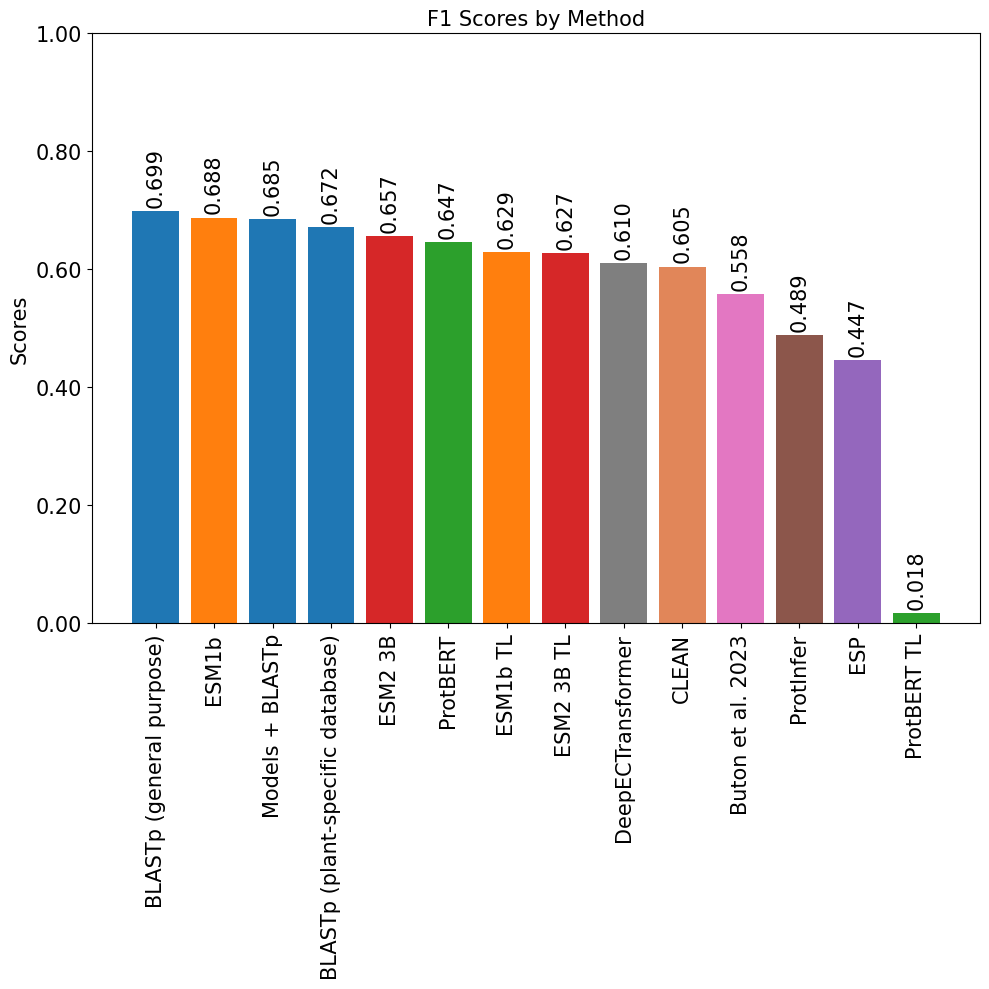

In [17]:
# plot all of them
import matplotlib.pyplot as plt

labels = ["Models + BLASTp", "BLASTp (general purpose)", "CLEAN", "ESM1b", "ProtBERT", "ESM2 3B", "ESM1b TL", "ProtBERT TL", "ESM2 3B TL", 
          "ESP", "ProtInfer", "Buton et al. 2023", "DeepECTransformer", "BLASTp (plant-specific database)"]
f1_scores = [ensemble_results[0], blast_results[0], clean_results[0], esm1b_results[0], protbert_results[0], 
             esm2_3b_results[0], esm1b_results_tl[0], protbert_results_tl[0], esm2_3b_results_tl[0], esp_results[0], 
             protinfer_results[0], buton_results[0], deepectransformer_results[0], blast_results_tl[0]]

f1_weighted_scores = [ensemble_results[1], blast_results[1], clean_results[1], esm1b_results[1], protbert_results[1],
                        esm2_3b_results[1], esm1b_results_tl[1], protbert_results_tl[1], esm2_3b_results_tl[1], esp_results[1],
                        protinfer_results[1], buton_results[1], deepectransformer_results[1]]
# precision_scores = [blast_results[1], clean_results[1], esm1b_results[1], protbert_results[1], esm2_3b_results[1]]
# recall_scores = [blast_results[2], clean_results[2], esm1b_results[2], protbert_results[2], esm2_3b_results[2]]

# Assign colors based on the model
colors = ["#1f77b4", "#1f77b4", "#e18659", "#ff7f0e", "#2ca02c", "#d62728", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
          "#1f77b4"]

# Combine the data into a list of tuples and sort it by F1 scores
data = list(zip(f1_scores, labels, colors))
data.sort(reverse=True, key=lambda x: x[0])  # Sort by F1 score in descending order

# Unpack the sorted data
f1_scores_sorted, labels_sorted, colors_sorted = zip(*data)

x = np.arange(len(labels_sorted))  # the label locations

# Create the plot
fig, ax = plt.subplots(figsize=(10, 10))
rects = ax.bar(x, f1_scores_sorted, color=colors_sorted)

# Add the scores on top of each bar
for rect, score in zip(rects, f1_scores_sorted):
    height = rect.get_height()
    ax.annotate(f'{score:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom',
                rotation=90, size=15)

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Scores', size=15)
ax.set_title('F1 Scores by Method', size=15)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(labels_sorted, size=15)
ax.xaxis.set_tick_params(rotation=90)

ax.set_yticklabels([f"{i:.2f}" for i in ax.get_yticks()], size=15)

fig.tight_layout()

plt.show()

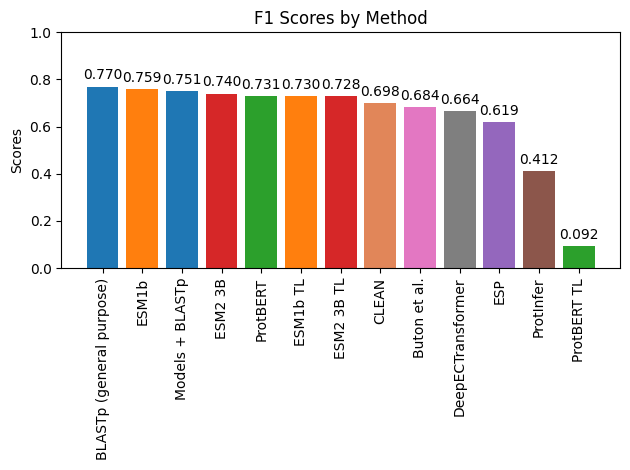

In [29]:
# precision_scores = [blast_results[1], clean_results[1], esm1b_results[1], protbert_results[1], esm2_3b_results[1]]
# recall_scores = [blast_results[2], clean_results[2], esm1b_results[2], protbert_results[2], esm2_3b_results[2]]

# Assign colors based on the model
colors = ["#1f77b4", "#1f77b4", "#e18659", "#ff7f0e", "#2ca02c", "#d62728", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"]

# Combine the data into a list of tuples and sort it by F1 scores
data = list(zip(f1_weighted_scores, labels, colors))
data.sort(reverse=True, key=lambda x: x[0])  # Sort by F1 score in descending order

# Unpack the sorted data
f1_scores_sorted, labels_sorted, colors_sorted = zip(*data)

x = np.arange(len(labels_sorted))  # the label locations

# Create the plot
fig, ax = plt.subplots()
rects = ax.bar(x, f1_scores_sorted, color=colors_sorted)

# Add the scores on top of each bar
for rect, score in zip(rects, f1_scores_sorted):
    height = rect.get_height()
    ax.annotate(f'{score:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Scores')
ax.set_title('F1 Scores by Method')
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels(labels_sorted)
ax.xaxis.set_tick_params(rotation=90)

fig.tight_layout()

plt.show()